In [1]:
!git clone https://github.com/juanmafdez/LLP_APP_Colombia

Cloning into 'LLP_APP_Colombia'...
remote: Enumerating objects: 285, done.
remote: Counting objects: 100% (285/285), done.
remote: Compressing objects: 100% (246/246), done.
remote: Total 285 (delta 105), reused 117 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (285/285), 3.52 MiB | 7.71 MiB/s, done.
Resolving deltas: 100% (105/105), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, sys, glob, json, shutil, random
import numpy as np
import pandas as pd
import geopandas as gpd
import tifffile
from pathlib import Path
from PIL import Image
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import tensorflow as tf

In [4]:
sys.path.append('LLP_APP_Colombia/swav')
import architecture
import multicrop_dataset

In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
data_path   = '/content/drive/MyDrive/llp_col_project/datasets/sentinel'
final_output = '/content/train_data'
os.makedirs(final_output, exist_ok=True)

In [7]:
departments = {
    'quindio': 'qui_partitions_aschips_13b98a63e407f'
}

for alias, folder_name in departments.items():
    print(f'--- Unzipping {alias} ---')
    !unzip -o -q {data_path}/{folder_name}.zip -d /content/
    full_path = f'/content/*/{folder_name}/sentinel2-rgb-median-2020'
    found_dirs = glob.glob(full_path)
    if found_dirs:
        src_dir = found_dirs[0]
        files = os.listdir(src_dir)
        print(f'Found files: {len(files)}')
        for f in files:
            src_file = os.path.join(src_dir, f)
            dst_file = os.path.join(final_output, f)
            shutil.move(src_file, dst_file)
        print(f'{alias} moved correctly.')
    else:
        print(f'{alias} not found.')
    !rm -rf /content/gjson_data*
print(f'Total files in {final_output}: {len(os.listdir(final_output))}')

--- Unzipping quindio ---
Found files: 1853
quindio moved correctly.
Total files in /content/train_data: 1853


In [8]:
GJSON_CHIPS = '/content/drive/MyDrive/llp_col_project/datasets/sentinel/geojson_sentinel/qui_partitions_aschips_13b98a63e407f.geojson'
GJSON_LABEL = '/content/drive/MyDrive/llp_col_project/datasets/esawc/quindio/qui_partitions_aschips_13b98a63e407f.geojson'

BACKBONE_WEIGHTS = '/content/drive/MyDrive/llp_col_project/swav_checkpoints/feature_backbone_latest.weights.h5'

SRC_DIR = '/content/train_data'
PNG_DIR = '/content/train_data_png8'
os.makedirs(PNG_DIR, exist_ok=True)

In [9]:
def save_png8_from_array(img_np: np.ndarray, out_path: str):
    if img_np.ndim == 3 and img_np.shape[0] < img_np.shape[1]:
        img_np = np.transpose(img_np, (1, 2, 0))
    elif img_np.ndim == 2:
        img_np = img_np[..., None]
    if img_np.shape[-1] == 1:
        img_np = np.repeat(img_np, 3, axis=-1)
    elif img_np.shape[-1] > 3:
        img_np = img_np[..., :3]
    arr = img_np.astype(np.uint8)
    Image.fromarray(arr).save(out_path, format='PNG', compress_level=0)

tif_paths = sorted(glob.glob(os.path.join(SRC_DIR, '*.tif')))
print(f'Converting {len(tif_paths)} TIFFs to PNG 8-bit...')
converted = 0
for p in tif_paths:
    out_path = os.path.join(PNG_DIR, Path(p).stem + '.png')
    if not os.path.exists(out_path):
        arr = tifffile.imread(p)
        save_png8_from_array(arr, out_path)
        converted += 1
print(f'Done. Converted: {converted}. '
      f'Total PNGs: {len(glob.glob(os.path.join(PNG_DIR, "*.png")))}')

Converting 1853 TIFFs to PNG 8-bit...
Done. Converted: 1853. Total PNGs: 1853


In [10]:
def extraer_prop_ewc(d):
    if isinstance(d, str):
        try:
            d = json.loads(d)
        except Exception:
            import ast
            d = ast.literal_eval(d)
    return float(d.get('1', 0.0))

gdf_chips = gpd.read_file(GJSON_CHIPS)
gdf_lab   = gpd.read_file(GJSON_LABEL)

gdf_lab['prop_chip'] = gdf_lab['esaworldcover-2020_proportions'].apply(extraer_prop_ewc)
chips = gdf_chips.merge(gdf_lab[['identifier', 'prop_chip', 'split_municipalities']], on='identifier', how='inner')

print(f'Total chips loaded: {len(chips)}')
print(f'Split distribution:\n{chips["split_municipalities"].value_counts()}')

Total chips loaded: 1853
Split distribution:
split_municipalities
train    1089
test      469
val       295
Name: count, dtype: int64


In [11]:
# -- Geographically correct split: train+val / test by municipality
# val is folded into train (no hyperparameter search / early stopping)
train_ids = chips.query("split_municipalities in ('train', 'val')")['identifier'].tolist()
test_ids  = chips.query("split_municipalities == 'test'")['identifier'].tolist()

print(f'\nTrain chips (train+val municipalities): {len(train_ids)}')
print(f'Test chips  (test municipalities):       {len(test_ids)}')
# print(f'Train municipalities: '
#       f'{chips.query("split_municipalities in (\"train\",\"val\")")["foreignid_municipalities"].nunique()}')
# print(f'Test  municipalities: '
#       f'{chips.query("split_municipalities == \"test\"")["foreignid_municipalities"].nunique()}')


Train chips (train+val municipalities): 1384
Test chips  (test municipalities):       469


In [12]:
def load_image(identifier: str) -> np.ndarray:
    path = os.path.join(PNG_DIR, identifier + '.png')
    img = Image.open(path).convert('RGB')
    return np.array(img, dtype=np.float32) / 255.0

# -- Build arrays -------------------------------------------
print('\nLoading train images...')
id_to_prop = dict(zip(gdf_lab['identifier'], gdf_lab['prop_chip']))

X_train = np.stack([load_image(i) for i in train_ids])
y_train = np.array([id_to_prop[i] for i in train_ids], dtype=np.float32)

print('Loading test images...')
X_test  = np.stack([load_image(i) for i in test_ids])
y_test  = np.array([id_to_prop[i] for i in test_ids], dtype=np.float32)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')
def load_image(identifier: str) -> np.ndarray:
    path = os.path.join(PNG_DIR, identifier + '.png')
    img = Image.open(path).convert('RGB')
    return np.array(img, dtype=np.float32) / 255.0

# -- Build arrays -------------------------------------------
print('\nLoading train images...')
id_to_prop = dict(zip(gdf_lab['identifier'], gdf_lab['prop_chip']))

X_train = np.stack([load_image(i) for i in train_ids])
y_train = np.array([id_to_prop[i] for i in train_ids], dtype=np.float32)

print('Loading test images...')
X_test  = np.stack([load_image(i) for i in test_ids])
y_test  = np.array([id_to_prop[i] for i in test_ids], dtype=np.float32)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')



Loading train images...
Loading test images...
X_train: (1384, 100, 100, 3) | y_train: (1384,)
X_test:  (469, 100, 100, 3)  | y_test:  (469,)

Loading train images...
Loading test images...
X_train: (1384, 100, 100, 3) | y_train: (1384,)
X_test:  (469, 100, 100, 3)  | y_test:  (469,)


In [13]:
# ===========================================================
# MODULE 5: Model builder
# ===========================================================

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

def build_model(pretrained: bool = False) -> tf.keras.Model:
    """
    ResNet backbone + single sigmoid head (matches LLP architecture).
    pretrained=True loads SwAV weights before adding the head.
    """
    backbone = architecture.get_resnet_backbone()
    if pretrained:
        backbone.load_weights(BACKBONE_WEIGHTS)
        print('SwAV weights loaded.')
    x = backbone.output
    x = Flatten()(x)
    x = Dense(1, activation='sigmoid', name='head')(x)
    model = Model(inputs=backbone.input, outputs=x)
    return model

# ===========================================================
# MODULE 6: Metrics
# ===========================================================

def compute_metrics(model, X, y, label=''):
    y_pred = model.predict(X, verbose=0).ravel()
    rmse   = float(np.sqrt(mean_squared_error(y, y_pred)))
    r, _   = pearsonr(y, y_pred)
    print(f'[{label}] RMSE: {rmse:.4f}  r: {r:.4f}')
    return {'rmse': rmse, 'r': r}

In [19]:
# ===========================================================
# MODULE 7: Training — Scratch
# ===========================================================

print('\n' + '='*50)
print('EXPERIMENT 1: Scratch (random initialization)')
print('='*50)

model_scratch = build_model(pretrained=False)
model_scratch.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse'
)

history_scratch = model_scratch.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128,
    verbose=1
)

print('\n--- Scratch: Final metrics ---')
scratch_train = compute_metrics(model_scratch, X_train, y_train, 'Train')
scratch_test  = compute_metrics(model_scratch, X_test,  y_test,  'Test')


EXPERIMENT 1: Scratch (random initialization)
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - loss: 0.1096 - val_loss: 0.0569
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 368ms/step - loss: 0.0720 - val_loss: 0.0562
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 373ms/step - loss: 0.0406 - val_loss: 0.0563
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 388ms/step - loss: 0.0275 - val_loss: 0.0565
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 379ms/step - loss: 0.0202 - val_loss: 0.0579
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 381ms/step - loss: 0.0185 - val_loss: 0.0663
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 416ms/step - loss: 0.0219 - val_loss: 0.0685
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 389ms/step - loss: 0.0259 - val_loss: 0.0671
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 391ms/step - loss: 0.0213 - val_loss: 0.0590
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 396ms/step - loss: 0.0212 - val_loss: 0.0601

--- Scratch: Final metrics ---
[Train] RMSE: 0.2192  r: 0.4996
[Test] RMSE: 0.2452  r: 0.5611

In [18]:
# ===========================================================
# MODULE 8: Training — SwAV pretrained
# ===========================================================

print('\n' + '='*50)
print('EXPERIMENT 2: SwAV pretrained')
print('='*50)

model_swav = build_model(pretrained=True)
model_swav.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='mse'
)

history_swav = model_swav.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=128,
    verbose=1
)

print('\n--- SwAV: Final metrics ---')
swav_train = compute_metrics(model_swav, X_train, y_train, 'Train')
swav_test  = compute_metrics(model_swav, X_test,  y_test,  'Test')


EXPERIMENT 2: SwAV pretrained
SwAV weights loaded.
Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - loss: 0.0534 - val_loss: 0.0501
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 352ms/step - loss: 0.0502 - val_loss: 0.0639
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 363ms/step - loss: 0.0491 - val_loss: 0.0519
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 363ms/step - loss: 0.0490 - val_loss: 0.0542
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 368ms/step - loss: 0.0485 - val_loss: 0.0536
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 376ms/step - loss: 0.0483 - val_loss: 0.0539
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 383ms/step - loss: 0.0482 - val_loss: 0.0541
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 386ms/step - loss: 0.0481 - val_loss: 0.0544
Epoch 9/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 418ms/step - loss: 0.0479 - val_loss: 0.0548
Epoch 10/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 399ms/step - loss: 0.0478 - val_loss: 0.0553

--- SwAV: Final metrics ---
[Train] RMSE: 0.2192  r: 0.1522
[Test] RMSE: 0.2351  r: 0.39

In [20]:
# ===========================================================
# MODULE 9: Summary table
# ===========================================================

import pandas as pd

summary = pd.DataFrame({
    'Method':    ['Scratch', 'SwAV'],
    'RMSE_test': [scratch_test['rmse'], swav_test['rmse']],
    'r_test':    [scratch_test['r'],    swav_test['r']],
    'RMSE_train':[scratch_train['rmse'],swav_train['rmse']],
    'r_train':   [scratch_train['r'],   swav_train['r']],
})

print('\n=== RESULTS SUMMARY ===')
print(summary.to_string(index=False))

output_path = '/content/drive/MyDrive/llp_col_project/experimental_results/supervised_chip_qui.csv'
summary.to_csv(output_path, index=False)
print(f'\nResults saved to: {output_path}')


=== RESULTS SUMMARY ===
 Method  RMSE_test   r_test  RMSE_train  r_train
Scratch   0.245189 0.561128    0.219230 0.499584
   SwAV   0.235128 0.392167    0.219241 0.152238

Results saved to: /content/drive/MyDrive/llp_col_project/experimental_results/supervised_chip_qui.csv


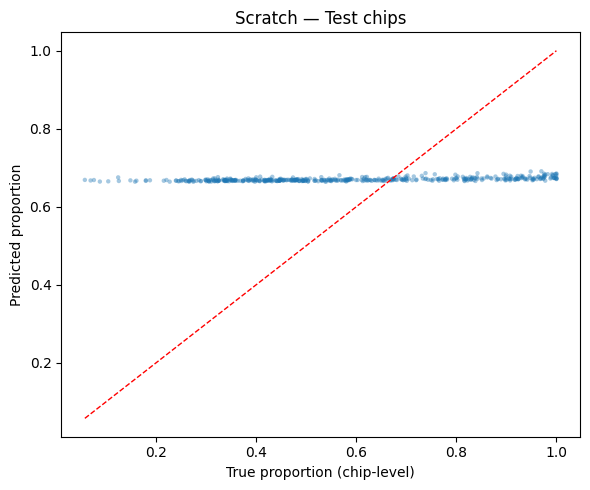

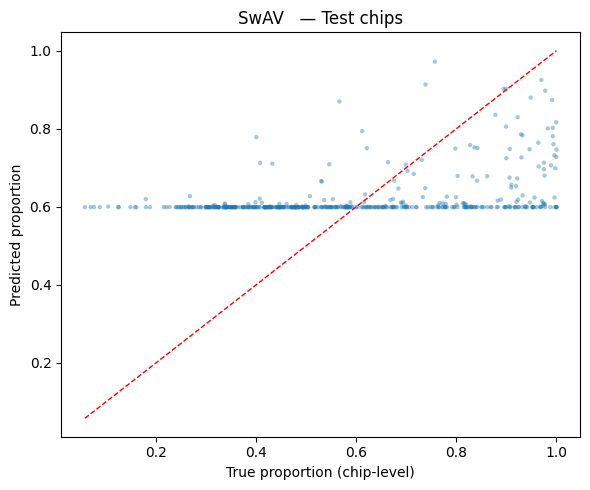

In [16]:
# ===========================================================
# MODULE 10: Scatter plots
# ===========================================================

import matplotlib.pyplot as plt

def scatter_plot(model, X, y, title):
    y_pred = model.predict(X, verbose=0).ravel()
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(y, y_pred, alpha=0.4, edgecolors='none', s=10)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlabel('True proportion (chip-level)')
    ax.set_ylabel('Predicted proportion')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

scatter_plot(model_scratch, X_test, y_test, 'Scratch — Test chips')
scatter_plot(model_swav,    X_test, y_test, 'SwAV   — Test chips')